# Today, worked from the table

The memory is six mornings. Busy and quiet each appear three times, so the whole table has no majority. Today is $(2, 2)$.

Squared distances: $9, 16, 25, 36, 64, 169$. Distances: $3, 4, 5, 6, 8, 13$. Order: A, B, C, D, E, F.


In [1]:
# Rebuild the order, then the three predictions that disagree on purpose.
from fractions import Fraction

order = [
    ("A", 3, "busy", 9),
    ("B", 4, "busy", 8),
    ("C", 5, "quiet", 3),
    ("D", 6, "quiet", 2),
    ("E", 8, "quiet", 1),
    ("F", 13, "busy", 6),
]
squares = [distance ** 2 for _, distance, _, _ in order]
assert squares == [9, 16, 25, 36, 64, 169]

def counts(k):
    labels = [row[2] for row in order[:k]]
    return labels.count("busy"), labels.count("quiet")

assert counts(1) == (1, 0)
assert counts(3) == (2, 1)
assert counts(5) == (2, 3)
busy = Fraction(1, 3) + Fraction(1, 4)
quiet = Fraction(1, 5) + Fraction(1, 6) + Fraction(1, 8)
assert busy == Fraction(70, 120)
assert quiet == Fraction(59, 120)
print("k=1 busy", counts(1))
print("k=3 busy", counts(3))
print("k=5 quiet", counts(5))
print("weighted k=5", busy, quiet)


k=1 busy (1, 0)
k=3 busy (2, 1)
k=5 quiet (2, 3)
weighted k=5 7/12 59/120


## What to tell someone about today

With one neighbor, today copies A and is busy. With three neighbors the vote is $2$ to $1$, still busy. With five neighbors the count flips to quiet, $3$ to $2$, but the weights $1/d$ flip it back: busy $70/120$, quiet $59/120$.

If the target is the busy-index $9, 8, 3$ on those three neighbors, the average is $20/3$ and the weighted average is $336/47$.

None of these sentences is a probability. Each one names $k$, the distance, and the vote rule. The scale of bookings and walk-ins was left alone because both counts are small whole numbers of the same kind. The visit example in the scaling lessons is the warning for the day when one column is recorded in a much larger unit.


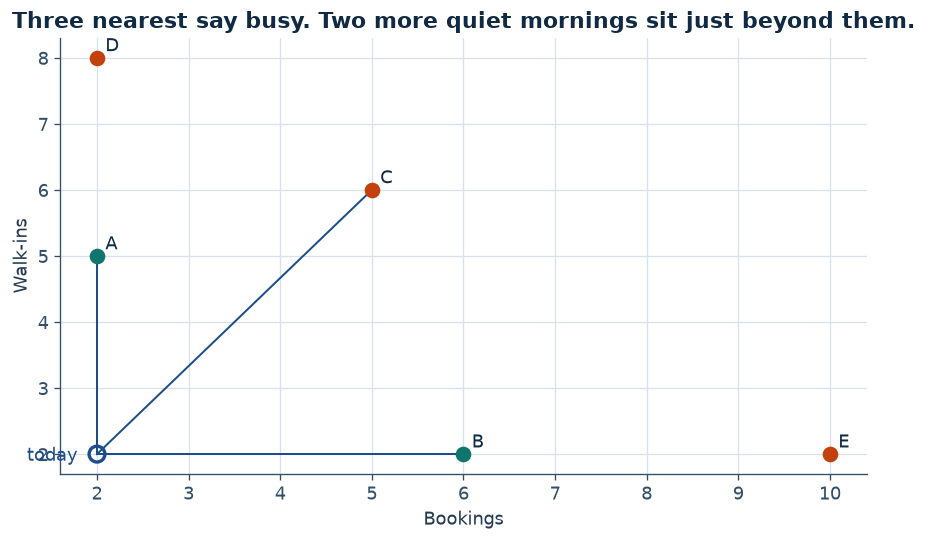

In [2]:
import matplotlib.pyplot as plt

# Quiet page. Busy is green, quiet is clay, and today is blue.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.4),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Today and the five neighbors used by the two conflicting rules.
points = [("A", 2, 5, GREEN), ("B", 6, 2, GREEN), ("C", 5, 6, CLAY),
          ("D", 2, 8, CLAY), ("E", 10, 2, CLAY)]
fig, ax = plt.subplots(constrained_layout=True)
for name, x, y, color in points:
    ax.scatter([x], [y], s=70, color=color, zorder=3)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(5, 4), color=INK)
ax.scatter([2], [2], s=90, facecolors="none", edgecolors=BLUE, linewidths=2, zorder=4)
ax.annotate("today", (2, 2), textcoords="offset points", xytext=(-42, -4), color=BLUE)
for name, x, y, _ in points[:3]:
    ax.plot([2, x], [2, y], color=BLUE, linewidth=1.2, zorder=2)
ax.set_xlabel("Bookings")
ax.set_ylabel("Walk-ins")
ax.set_title("Three nearest say busy. Two more quiet mornings sit just beyond them.")


## The habit

1. Keep the stored rows. They are the model.
2. Write the distance, the value of $k$, and the tie rule before you sort.
3. Rank by squared distance when the distance is Euclidean, and switch to absolute gaps only when you mean Manhattan.
4. Scale from the stored rows alone when the columns do not share a unit.
5. For a label, count or add $1/d$. For a number, average, with the same weights.
6. Hide a row before you score it. Distance zero is a copy, not a success.

On this table the short version is: A is nearest, three neighbors still say busy, five unweighted neighbors say quiet, and five weighted neighbors say busy again.
